In [ ]:
#in the current notebook, i would like to do the following things:
#dataset loading
#sparsity analysis
#target analysis
#constant features
#initial EDA notebook

#the dataset can be found in the data directory "train.csv"

#please help me code a clean, repeatable notebook that shows how its done and why

In [16]:
# lets start by loading our dataset and taking a look at it
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("data/train.csv")
train_df.head() #shows that only ID and target are named, the rest has random names and looks sparse, lets check how many zeros are in the dataset
# we can do this by using the .value_counts() method on each column and checking for the number of zeros, but then we would print 4993 lines of output
# instead we can count the total amount of zeros in the dataset and divide it by the total number of values to get a sparsity percentage
total_values = train_df.size # total number of values in the dataset
total_zeros = (train_df == 0).sum().sum() # total number of zeros
sparsity_percentage = (total_zeros / total_values) * 100
print(f"Sparsity percentage: {sparsity_percentage:.2f}%") # this shows that the dataset is very sparse, with a sparsity percentage of 96.82%

Sparsity percentage: 96.82%


In [18]:
total_cells = np.product(train_df.shape)

missing_cells = train_df.isna().sum().sum()

missing = missing_cells / total_cells

print(f"missing values: {missing:.2%}")

#how many values are non-zero outside of ID and target columns?
non_zero_values = (train_df.drop(columns=["ID", "target"]) != 0).sum().sum()
print(f"Non-zero values (excluding ID and target): {non_zero_values}")

#show share of non-zero values per column in a table, only displaying the top 20 with the most non-zero values
non_zero_cols = (train_df.drop(columns=["ID", "target"]) != 0).sum().sort_values(ascending=False)
non_zero_cols.head()

#count of columns that contain non-zero values
print(f"there are {(non_zero_cols != 0).sum()} columns containing non-zero values outside of target and ID")
print(f"and {(non_zero_cols == 0).sum()} columns containing nothing but zeros")





missing values: 0.00%
Non-zero values (excluding ID and target): 700109
there are 4735 columns containing non-zero values outside of target and ID
and 256 columns containing nothing but zeros


In [19]:
# check out if completely empty columns carry non-zeros in test data
train_all_zero_cols = [
    col for col in train_df.columns
    if col != "target" and (df[col] == 0).all()
]

test_df = pd.read_csv("data/test.csv")

test_nonzero_in_train_zero = []

for col in train_all_zero_cols:

    if col in test_df.columns:
        if (test_df[col] != 0).any():
            test_nonzero_in_train_zero.append(col)

print(
    f"{len(test_nonzero_in_train_zero)} columns "
    "are zero in train but non-zero in test"
)

#still remove these from train data since:
#the model cannot learn from a feature with zero variance in training
#no relationship to target can be learned 
#test-only information is unusable for supervised learning

256 columns are zero in train but non-zero in test


In [20]:
train_zero_pct = (df == 0).mean()
test_zero_pct = (test_df == 0).mean()

sparsity_compare = pd.DataFrame({
    "train_zero_pct": train_zero_pct,
    "test_zero_pct": test_zero_pct
})

sparsity_compare["difference"] = (
    sparsity_compare["test_zero_pct"]
    - sparsity_compare["train_zero_pct"]
).abs()

sparsity_compare.sort_values(
    "difference",
    ascending=False
).head(20)

,train_zero_pct,test_zero_pct,difference
0ff32eb98,0.649024,0.918467,0.269443
c5a231d81,0.649024,0.901666,0.252641
c47340d97,0.651267,0.894633,0.243366
adb64ff71,0.653061,0.890803,0.237742
0572565c2,0.653061,0.883284,0.230223
91f701ba2,0.650146,0.879717,0.229571
190db8488,0.657322,0.886365,0.229042
fc99f9426,0.659565,0.879697,0.220132
6619d81fc,0.656201,0.873617,0.217416
1db387535,0.657995,0.875056,0.217061


In [57]:
#target analysis
TARGET = "target"
print(train_df[TARGET].shape)

print(train_df[TARGET].isna().sum())

print(train_df[TARGET].nunique())

train_df[TARGET].value_counts()

(
    train_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

(4459,)
0
1413


target
2000000.0     4.64
10000000.0    4.46
20000000.0    3.50
4000000.0     3.32
1000000.0     2.89
              ... 
19552000.0    0.02
13598000.0    0.02
3442000.0     0.02
7800000.0     0.02
1065000.0     0.02
Name: proportion, Length: 1413, dtype: float64

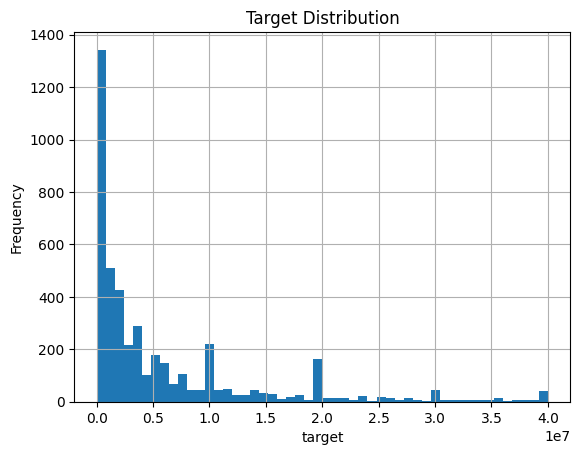

In [ ]:
train_df[TARGET].hist(bins=50)

plt.title("Target Distribution")
plt.xlabel(TARGET)
plt.ylabel("Frequency")
plt.show()

In [29]:
train_df[TARGET].describe()

count    4.459000e+03
mean     5.944923e+06
std      8.234312e+06
min      3.000000e+04
25%      6.000000e+05
50%      2.260000e+06
75%      8.000000e+06
max      4.000000e+07
Name: target, dtype: float64

In [ ]:
#check skewness
train_df[TARGET].skew()

2.0859665375858056

| Skew | Meaning               |
| ---- | --------------------- |
| ~0   | symmetric             |
| >1   | strongly right-skewed |
| <-1  | strongly left-skewed  |


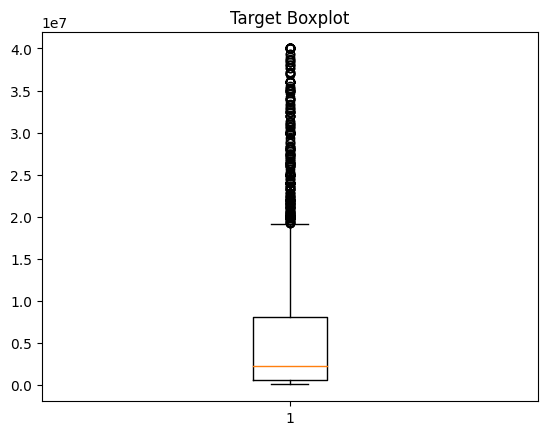

In [ ]:
#chekc outliers
plt.boxplot(train_df[TARGET])
plt.title("Target Boxplot")
plt.show()

chosen evaluation metric by Kaggle: Mean Squared Logarithmic Error (MSLE)

MSLE penalizes:

* underprediction more than overprediction (in log space)
* errors on large values heavily
* requires non-negative predictions
* behaves like RMSE on log(1 + y)

In [ ]:
#constant features
#identify and drop because they only add computational cost & they can destabilize regularization
constant_cols = [
    col for col in train_df.columns
    if train_df[col].nunique() <= 1
]

len(constant_cols)

train_df = train_df.drop(columns=constant_cols)
test_df = test_df.drop(columns=constant_cols, errors="ignore")

In [37]:
#row wise statistics
feature_cols = train_df.drop(columns=[TARGET]).select_dtypes(include="number").columns

train_df["row_sum"] = train_df[feature_cols].sum(axis=1)
train_df["row_mean"] = train_df[feature_cols].mean(axis=1)
train_df["row_std"] = train_df[feature_cols].std(axis=1)
train_df["row_nonzero"] = (train_df[feature_cols] != 0).sum(axis=1)
train_df["row_sum_log"] = np.log1p(train_df[feature_cols].sum(axis=1))



| Feature     | Meaning                    |
| ----------- | -------------------------- |
| row_sum     | overall activity intensity |
| row_nonzero | number of active signals   |
| row_std     | diversity of signals       |


variance ranking 
Interpretation:
Low variance
almost constant
usually useless
often safe to drop
High variance
strong spread
potentially informative
OR noisy encoding artifact (important to verify)



In [40]:
#variance ranking
variance = train_df[feature_cols].var().sort_values(ascending=False)
variance.describe()
variance.head(20)

row_sum      2.319112e+19
row_std      4.909969e+15
3be4dad48    4.861781e+15
3d23e8abd    4.861418e+15
625525b5d    4.859560e+15
9fa984817    4.859074e+15
2b85882ad    4.858712e+15
07cb6041d    4.858359e+15
4ceef6dbd    4.858139e+15
df6a71cc7    4.857263e+15
ede70bfea    4.856409e+15
f1c272f04    1.380199e+15
b77c707ef    1.343336e+15
1029d9146    1.206092e+15
ff3b49c1d    1.187903e+15
56cb93fd8    1.185987e+15
4c835bd02    1.181351e+15
c059f2574    1.178067e+15
33e4f9a0e    1.176782e+15
6488c8200    5.639571e+14
dtype: float64

In [42]:
#identify near constant features:
low_variance_cols = variance[variance < 1e-4].index

len(low_variance_cols)

0

🔍 Key insight

You are NOT in a:

“binary sparse matrix problem”

You are in a:

“zero-inflated continuous feature space”

This is VERY common in:

event prediction
engagement modeling
recommendation systems
scraped behavioral datasets
🚨 Why your current pruning logic fails

This is important:

variance < 1e-6

👉 assumes features are:

normalized
stable scale
mostly binary or low-range

But your dataset is:

sparse + heavy-tailed

So variance filtering becomes meaningless.

In [46]:
binary_cols = [
    col for col in feature_cols
    if train_df[col].dropna().isin([0, 1]).all()
]

len(binary_cols)

0

In [ ]:
nonzero_stats = train_df[feature_cols].apply(lambda x: x[x != 0].describe())
nonzero_mean = train_df[feature_cols].where(train_df[feature_cols] != 0).mean()
nonzero_std = train_df[feature_cols].where(train_df[feature_cols] != 0).std()
activation_rate = (train_df[feature_cols] != 0).mean()
activation_rate.describe()

count    4739.000000
mean        0.033976
std         0.056133
min         0.000224
25%         0.003476
50%         0.015923
75%         0.040368
max         1.000000
dtype: float64

In [51]:
train_df[feature_cols].where(train_df[feature_cols] != 0).stack().describe()

count    7.179450e+05
mean     2.614924e+07
std      4.384693e+08
min      2.557491e+00
25%      4.312920e+05
50%      2.000000e+06
75%      7.200000e+06
max      4.549715e+10
dtype: float64

Interpretation
A) Extremely heavy-tailed positive values

You have:

small baseline values (~2–10)
medium mass (~1e5–1e7)
extreme outliers (~1e10)

👉 This is a power-law / log-distributed feature space

B) This confirms:

Your features are:

❌ NOT one-hot
❌ NOT normalized
❌ NOT bounded
❌ NOT low-variance engineered binary signals

In [54]:
signal_strength = train_df[feature_cols].max() - train_df[feature_cols].min()
mean_nonzero = train_df[feature_cols].where(train_df[feature_cols] != 0).mean()

In [55]:
nonzero_df = train_df[feature_cols][train_df[feature_cols] != 0]

nonzero_df.describe(percentiles=[0.5, 0.9, 0.99])

,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,20aa07010,dc5a8f1d8,...,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466,row_sum,row_mean,row_std,row_nonzero
count,3.900000e+01,4.000000e+00,3.300000e+01,2.000000e+00,5.000000e+00,4.700000e+01,5.000000e+00,5.000000e+00,1.494000e+03,1.230000e+02,...,1.0,3.500000e+01,1.800000e+01,3.400000e+01,8.000000e+01,1.630000e+02,4.459000e+03,4.459000e+03,4.459000e+03,4459.000000
mean,1.675547e+06,1.550500e+06,3.610770e+06,1.010000e+07,2.355240e+07,2.913350e+06,1.504040e+07,4.164000e+06,7.668666e+06,5.626890e+06,...,640000.0,1.546393e+07,8.852233e+06,4.096694e+07,5.138975e+06,6.234666e+06,2.780301e+09,8.803595e+05,4.053699e+07,161.010316
std,3.863460e+06,1.714084e+06,5.649028e+06,6.646804e+06,4.317986e+07,4.867345e+06,1.861694e+07,4.209332e+06,1.538301e+07,7.815666e+06,...,NaN,5.174683e+07,2.451555e+07,2.834446e+07,1.117009e+07,7.251597e+06,4.815716e+09,1.524676e+06,7.007117e+07,212.085541
min,2.800000e+04,6.000000e+03,3.000000e+04,5.400000e+06,5.400000e+04,1.440000e+05,6.000000e+03,6.000000e+05,2.000000e+03,6.000000e+02,...,640000.0,5.000000e+04,4.000000e+04,1.700000e+05,2.000000e+04,5.348000e+03,8.059975e+03,2.557491e+00,1.306990e+02,5.000000
50%,2.800000e+05,1.098000e+06,1.070000e+06,1.010000e+07,2.560000e+06,8.400000e+05,4.000000e+06,2.000000e+06,2.200000e+06,2.800000e+06,...,640000.0,1.116000e+06,3.420000e+06,5.000000e+07,3.000000e+06,2.800000e+06,1.061747e+09,3.361917e+05,1.551513e+07,107.000000
90%,5.000000e+06,3.158800e+06,9.401800e+06,1.386000e+07,6.600000e+07,1.000000e+07,3.600000e+07,8.880000e+06,2.000000e+07,1.010880e+07,...,640000.0,2.108000e+07,1.000000e+07,5.415800e+07,4.960000e+06,1.465000e+07,6.875363e+09,2.176754e+06,9.996293e+07,323.000000
99%,1.620000e+07,3.915880e+06,1.994560e+07,1.470600e+07,9.660000e+07,1.971992e+07,3.960000e+07,1.024800e+07,5.860500e+07,4.088000e+07,...,640000.0,2.233459e+08,9.002860e+07,1.268000e+08,5.254712e+07,2.638924e+07,2.497018e+10,7.905784e+06,3.631262e+08,1073.420000
max,2.000000e+07,4.000000e+06,2.000000e+07,1.480000e+07,1.000000e+08,2.070800e+07,4.000000e+07,1.040000e+07,3.196120e+08,6.000000e+07,...,640000.0,3.013120e+08,1.064200e+08,1.400000e+08,6.176800e+07,4.320000e+07,4.549715e+10,1.440344e+07,6.611257e+08,1993.000000


In [56]:
log_features = np.log1p(train_df[feature_cols])
log_features.describe()

,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,20aa07010,dc5a8f1d8,...,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466,row_sum,row_mean,row_std,row_nonzero
count,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,...,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000
mean,0.111931,0.011597,0.101112,0.007179,0.016260,0.147267,0.016286,0.016526,4.833026,0.401985,...,0.002998,0.112875,0.058852,0.129519,0.254749,0.523774,20.437189,12.379943,16.216014,4.476548
std,1.201321,0.394242,1.183108,0.339115,0.494329,1.432660,0.497698,0.494549,6.912867,2.407644,...,0.200211,1.281893,0.930329,1.483744,1.899237,2.722828,1.999170,1.997785,1.989653,1.174083
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.994790,1.269055,4.880519,1.791759
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.343620,11.286125,15.127527,3.663562
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.783181,12.725440,16.557327,4.682131
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.304687,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.835816,13.778065,17.606282,5.308268
max,16.811243,15.201805,16.811243,16.510138,18.420681,16.846031,17.504390,16.157316,19.582618,17.909855,...,13.369225,19.523657,18.482904,18.757153,17.938896,17.581351,24.540916,16.482977,20.309455,7.597898


In [63]:
#target aware filtering
y = np.log1p(train_df[TARGET])
corr = train_df[feature_cols].corrwith(y)
weak_signal = corr[abs(corr) < 0.001].index

In [64]:
# feature removal
low_activation = activation_rate[activation_rate < 0.0005].index #never active enough to matter
high_activation = activation_rate[activation_rate > 0.999].index #Always active → no discriminative power
no_signal_variation = nonzero_std[nonzero_std == 0].index #No signal variation when active
nonzero_count = train_df[feature_cols].astype(bool).sum() 

rare_cols = nonzero_count[nonzero_count < 10].index

print(f"{len(low_activation)} columns are not active enough to matter for modeling")
print(f"{len(high_activation)} columns are always active → no discriminative power for modeling")
print(f"{len(no_signal_variation)} columns carry no signal variation when active")
print(f"{len(rare_cols)} columns with unstable signal, high noise risk and low generalization")

behavioral_drop = set(low_activation) \
                | set(high_activation) \
                | set(no_signal_variation) \
                | set(rare_cols)


373 columns are not active enough to matter for modeling
4 columns are always active → no discriminative power for modeling
12 columns carry no signal variation when active
1007 columns with unstable signal, high noise risk and low generalization


In [68]:
drop_cols = set(constant_cols) \
          | set(behavioral_drop) \
          | set(weak_signal)


print(f"We will drop {len(constant_cols)} columns, because they dont ever change and are thus irrelevant for training")
print(f"We might drop {len(behavioral_drop)} columns, as plausible noise candidates, but also containing high-value signals")
print(f"We might drop {len(weak_signal)} columns, because they basically do not correlate with our target but high-risk statistical filter!")

We will drop 256 columns, because they dont ever change and are thus irrelevant for training
We might drop 1015 columns, as plausible noise candidates, but also containing high-value signals
We might drop 163 columns, because they basically do not correlate with our target but high-risk statistical filter!


In [69]:
#Quick LightGBM baseline on raw data
TARGET = "target"
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error


kf = KFold(n_splits=5, shuffle=True, random_state=42)

msle_scores = []

for train_idx, val_idx in kf.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50)]
    )

    preds = model.predict(X_val)

    preds = np.clip(preds, 0, None)  # MSLE requires non-negative

    msle = mean_squared_log_error(y_val, preds)
    msle_scores.append(msle)

print("CV MSLE:", np.mean(msle_scores), "+/-", np.std(msle_scores))

ModuleNotFoundError: No module named 'lightgbm'

In [ ]:
# train on log target
y_log = np.log1p(y)
model.fit(X_train, y_log_train)
preds_log = model.predict(X_val)
preds = np.expm1(preds_log)
preds = np.clip(preds, 0, None)
msle = mean_squared_log_error(y_val, preds)